# Demo: `measured.summary(...)`

This notebook demonstrates the intended PMV workflow: keep `RangeScene` for the fixed-assumption background map, then add measured-data overlay and summary using `measured.summary(...)`.

Workflow:

- Build a standard PMV `RangeScene` background plot.
- Pass measured points separately.
- Let `measured.summary(...)` compute PMV row by row, categorize the points, overlay them on the background, and add the compact summary panel.

In [1]:
import matplotlib.pyplot as plt
import measured
import pandas as pd
from range_scene import RangeScene

from pythermalcomfort.models import pmv_ppd_iso

A small measured dataset is used here so the PMV example stays easy to discuss in a live meeting.

In [2]:
df = pd.DataFrame(
    {
        "tdb": [20.0, 22.0, 23.5, 24.5, 26.0, 27.5, 29.0, 20.0],
        "rh": [50.0, 45.0, 50.0, 50.0, 55.0, 60.0, 60.0, 65.0],
        "tr": [20.0, 21.5, 23.5, 24.5, 26.0, 28.0, 29.5, 20.0],
        "vr": [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10],
        "met": [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
        "clo": [0.90, 0.80, 0.60, 0.50, 0.50, 0.40, 0.35, 0.80],
        "wme": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    }
)

df

,tdb,rh,tr,vr,met,clo,wme
0,20.0,50.0,20.0,0.1,1.2,0.90,0.0
1,22.0,45.0,21.5,0.1,1.2,0.80,0.0
2,23.5,50.0,23.5,0.1,1.2,0.60,0.0
3,24.5,50.0,24.5,0.1,1.2,0.50,0.0
4,26.0,55.0,26.0,0.1,1.2,0.50,0.0
5,27.5,60.0,28.0,0.1,1.2,0.40,0.0
6,29.0,60.0,29.5,0.1,1.2,0.35,0.0
7,20.0,65.0,20.0,0.1,1.2,0.80,0.0


Step 1: create the fixed-assumption PMV background with `RangeScene` in the usual way.

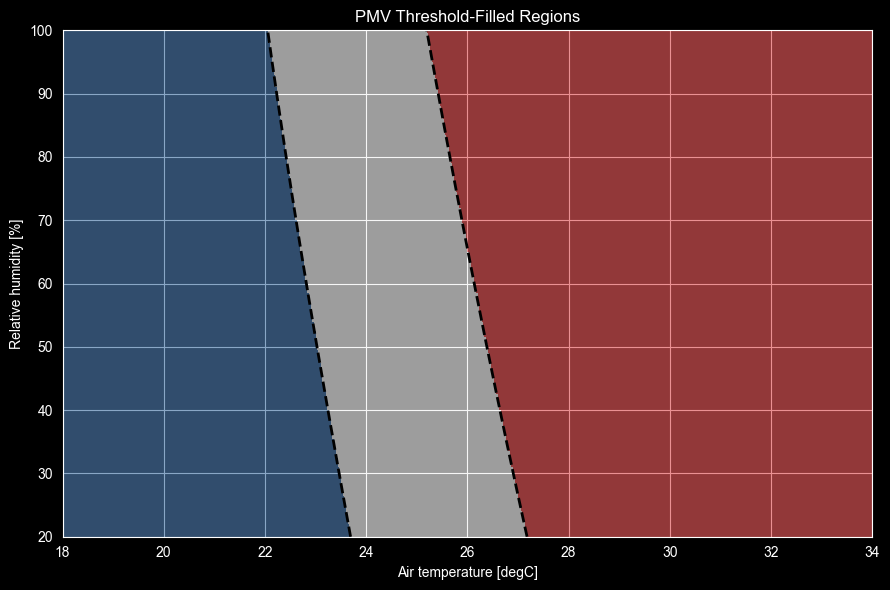

In [3]:
scene = (
    RangeScene(model_func=pmv_ppd_iso)
    .x(tdb=(18.0, 34.0))
    .y(rh=(20.0, 100.0))
    .parameters(
        vr=0.10,
        met=1.2,
        clo=0.5,
        wme=0.0,
    )
)

result = scene.plot(
    output="pmv",
    levels=[-0.5, 0.5],
    x_step=0.2,
    y_step=0.5,
    show_lines=True,
    line_kws={"color": "black", "linewidth": 2.0, "linestyle": "--"},
    fill_kws={"alpha": 0.65},
    legend=False,
)

result.ax.set_title("PMV Threshold-Filled Regions")
result.ax.set_xlabel("Air temperature [degC]")
result.ax.set_ylabel("Relative humidity [%]")

plt.tight_layout()
plt.show()

Step 2: call `measured.summary(...)` on the existing `plot=result`. The helper computes measured PMV and categories outside `RangeScene`, overlays the points, and adds the right-side summary panel.

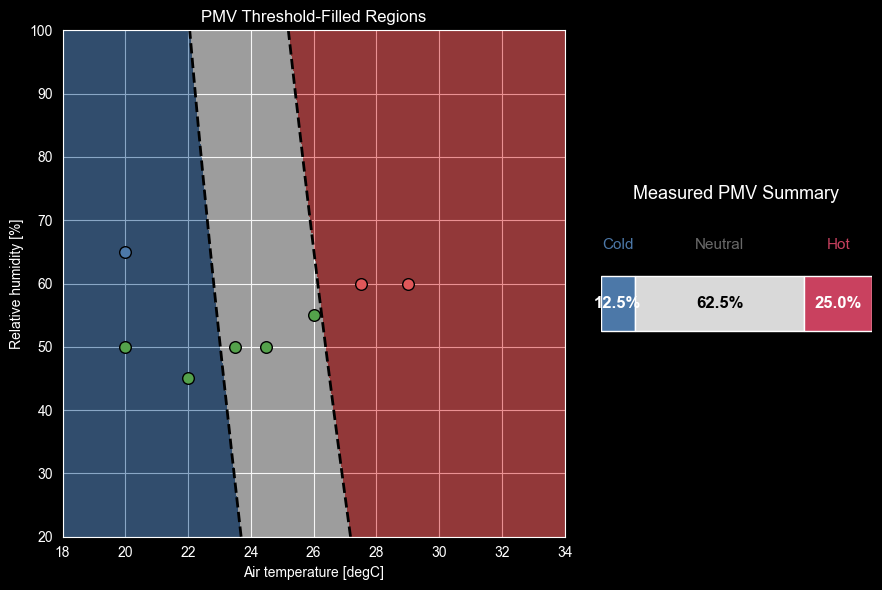

In [4]:
summary_result = measured.summary(df=df, plot=result)

The helper returns the processed dataframe and the measured category percentages so the computed results remain inspectable.

In [5]:
summary_result.data

,tdb,rh,tr,vr,met,clo,wme,pmv,category
0,20.0,50.0,20.0,0.1,1.2,0.90,0.0,-0.50,Neutral
1,22.0,45.0,21.5,0.1,1.2,0.80,0.0,-0.28,Neutral
2,23.5,50.0,23.5,0.1,1.2,0.60,0.0,-0.16,Neutral
3,24.5,50.0,24.5,0.1,1.2,0.50,0.0,-0.06,Neutral
4,26.0,55.0,26.0,0.1,1.2,0.50,0.0,0.42,Neutral
5,27.5,60.0,28.0,0.1,1.2,0.40,0.0,0.86,Hot
6,29.0,60.0,29.5,0.1,1.2,0.35,0.0,1.31,Hot
7,20.0,65.0,20.0,0.1,1.2,0.80,0.0,-0.60,Cold


In [6]:
summary_result.category_percentages

category
Cold       12.5
Neutral    62.5
Hot        25.0
Name: proportion, dtype: float64